# Node neighbourhood similarity compared to node encoding distance for various structural encodings

Compare various structural encodings on how they capture the similarity of the nodes in the graphs.

In [61]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd

BASE_PATH = "../lpca_out/"
SIM_PATH = "../output/similarity_res/"
PROPERTIES_PATH = "../output/properties/"

In [62]:
plt.rcParams.update({'font.size': 16})

In [63]:
def plot_neighbourhood_distance_multiple(df_paths, title):
    plt.rcParams.update({'font.size': 16})
    for label, df_path in df_paths.items():
        df = pd.read_parquet(df_path)
        data = df.groupby("d")["sim"].agg(["mean", "std"])

        plt.errorbar(data.index, data["mean"], yerr=data["std"], fmt='-o', capsize=0.2, capthick=1, label=label)
    plt.xlabel("neighbourhood symmetric difference")
    plt.ylabel("average distance between \n distinct node encoding pairs")
    plt.title(title)
    plt.legend()
    plt.legend()
    plt.savefig("neighbourhood_similarity_plot.png")
    plt.show()

In [64]:
def plot_neighbourhood_similarity_multiple(df_paths, title):
    plt.rcParams.update({'font.size': 16})
    for label, df_path in df_paths.items():
        df = pd.read_parquet(df_path)
        data = df.groupby("d")["sim"].agg(["mean", "std"])

        plt.errorbar(data.index, data["mean"], yerr=data["std"], fmt='-o', capsize=0.2, capthick=1, label=label)
    plt.xlabel("new similarity score")
    plt.ylabel("average distance between \n distinct node encoding pairs")
    plt.title(title)
    plt.legend()
    plt.legend()
    plt.savefig("neighbourhood_similarity_plot.png")
    plt.show()

In [65]:
def plot_neighbourhood_distance_single(df_paths, i, title):
    plt.rcParams.update({'font.size': 16})
    for label, df_path in df_paths.items():
        df = pd.read_parquet(df_path)
        data = df.iloc[i]

        plt.errorbar(range(data["d_mean"].size), data["d_mean"], yerr=data["d_std"], fmt='-o', capsize=0.2, capthick=1, label=label)
    plt.xlabel("neighbourhood symmetric difference")
    plt.ylabel("average distance between \n distinct node encoding pairs")
    plt.title(title)
    plt.legend()
    plt.savefig("neighbourhood_similarity_plot.png")
    plt.show()

In [66]:
def plot_neighbourhood_similarity_single(df_paths, i, title):
    plt.rcParams.update({'font.size': 16})
    for label, df_path in df_paths.items():
        df = pd.read_parquet(df_path)
        data = df.iloc[i]

        plt.errorbar(range(data["d_mean"].size), data["d_mean"], yerr=data["d_std"], fmt='-o', capsize=0.2, capthick=1, label=label)
    plt.xlabel("new similarity score")
    plt.ylabel("average distance between \n distinct node encoding pairs")
    plt.title(title)
    plt.legend()
    plt.savefig("neighbourhood_similarity_plot.png")
    plt.show()

In [67]:
def plot_error(df_paths):
    for label, df_path in df_paths.items():
        df = pd.read_parquet(df_path)
        error = df["error"]
        
        error_mean = error.mean()
        error_std = error.std()
        display(f"{label}: reconstruction error mean = {error_mean}, std = {error_std}")

        plt.hist(error, align="left", range=(0,1), edgecolor="black", linewidth=1)
        plt.title(f"Reconstruction Error hist for {label}")
        plt.xlabel("Error")
        plt.ylabel("number of node pairs")
        plt.show()

'Sim, ZINC, gamma=0.3: reconstruction error mean = 0.007460536900907755, std = 0.051385946571826935'

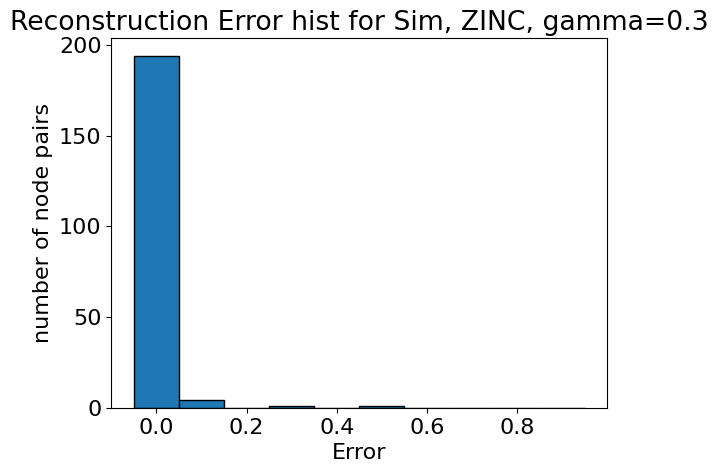

'Sim, ZINC, gamma=1.0: reconstruction error mean = 0.0007372097461484373, std = 0.010425720363855362'

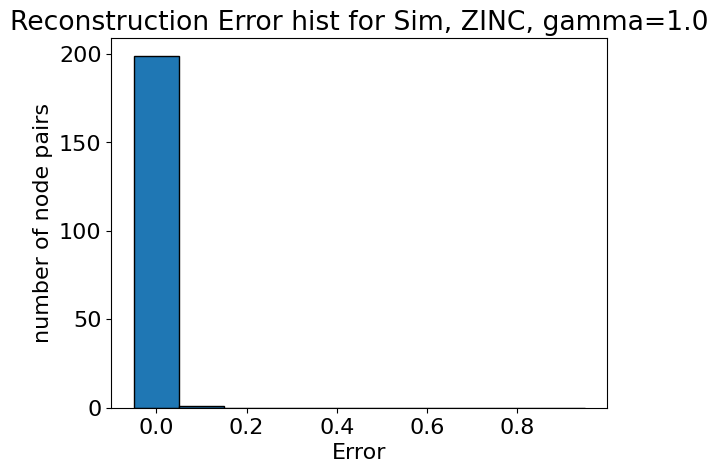

'Sim, Peptides, gamma=0.3: reconstruction error mean = 0.10841712355613708, std = 0.20454062521457672'

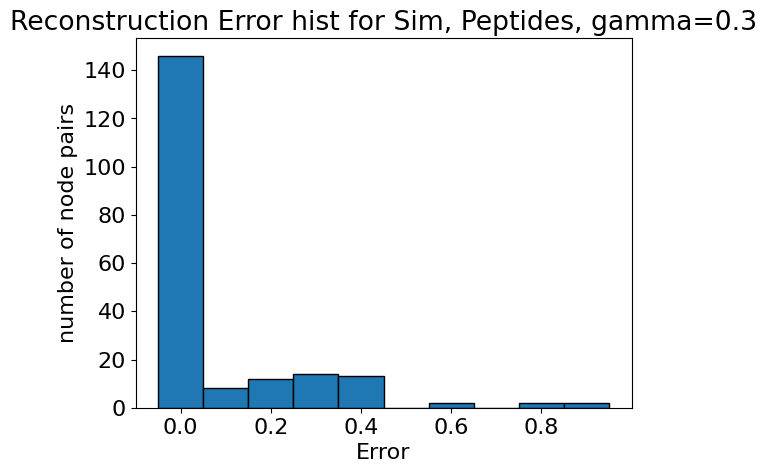

'Sim, Peptides, gamma=1.0: reconstruction error mean = 0.3560052514076233, std = 0.2539563775062561'

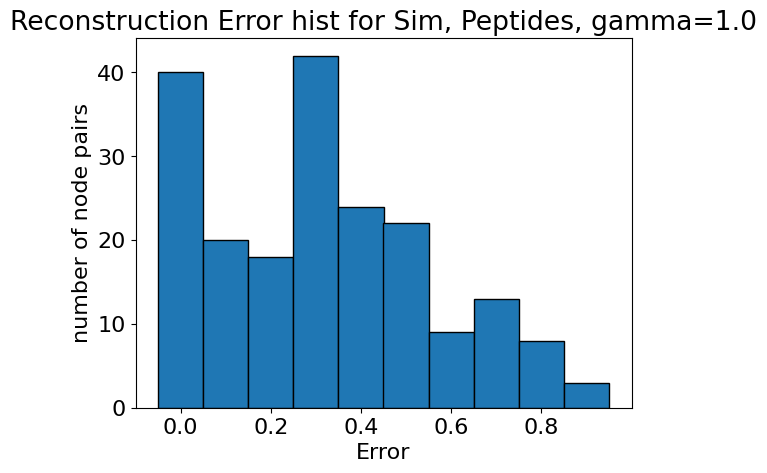

'Sim, CIFAR, gamma=0.3: reconstruction error mean = 0.0, std = 0.0'

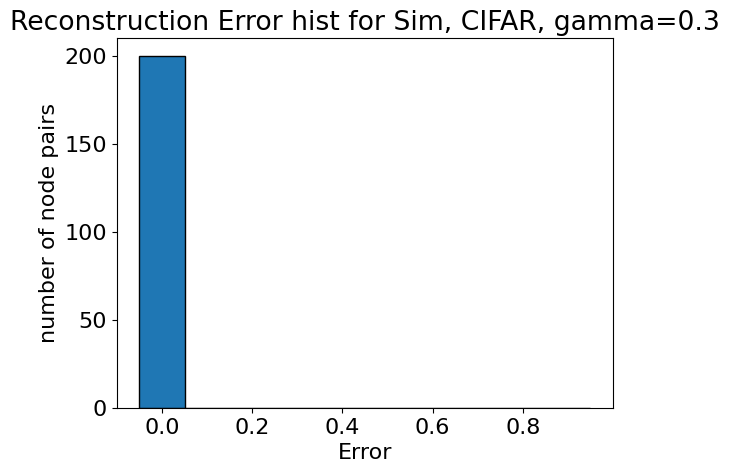

'Sim, CIFAR, gamma=1.0: reconstruction error mean = 0.09528603404760361, std = 0.049046579748392105'

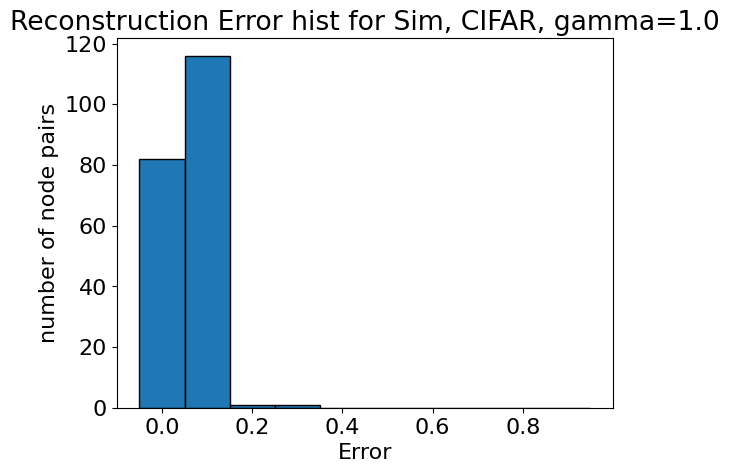

In [68]:
plot_error({f"Sim, ZINC, gamma={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodSim_k8_b4_gamma{g}_s200.parquet" for g in [0.3, 1.0]})
plot_error({f"Sim, Peptides, gamma={g}": BASE_PATH + f"lpca_with_sim_new_Peptides_methodSim_k8_b4_gamma{g}_s200.parquet" for g in [0.3, 1.0]})
plot_error({f"Sim, CIFAR, gamma={g}": BASE_PATH + f"lpca_with_sim_new_CIFAR_methodSim_k12_b4_gamma{g}_s200.parquet" for g in [0.3, 1.0]})

'Dist, ZINC, gamma=0.0: reconstruction error mean = 0.0, std = 0.0'

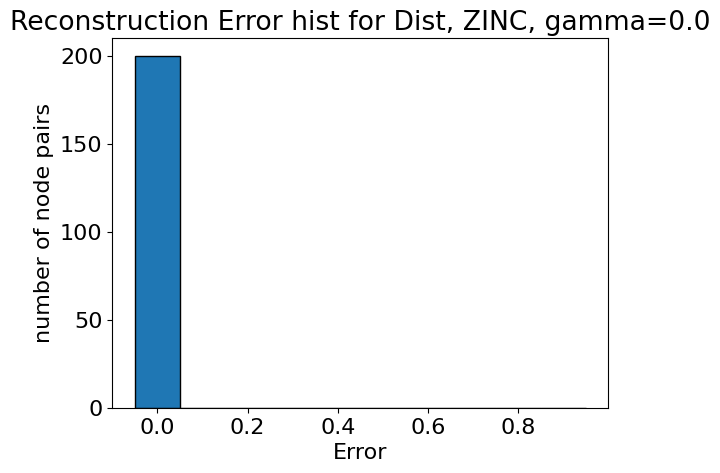

'Dist, ZINC, gamma=0.3: reconstruction error mean = 0.003671125741675496, std = 0.03677515313029289'

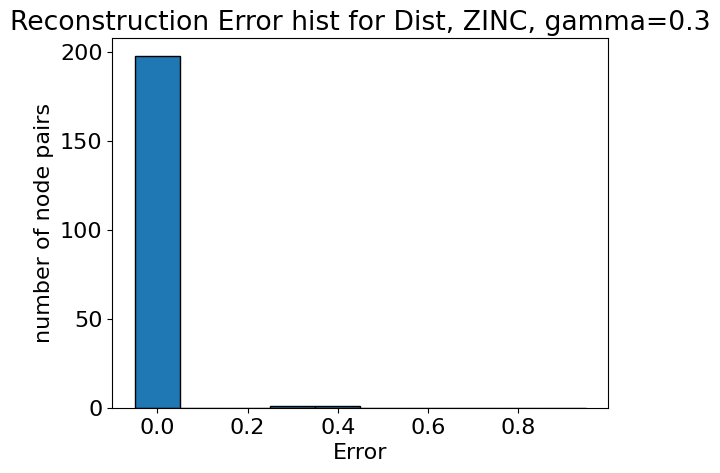

'Dist, ZINC, gamma=1.0: reconstruction error mean = 0.005595577415078878, std = 0.03914026543498039'

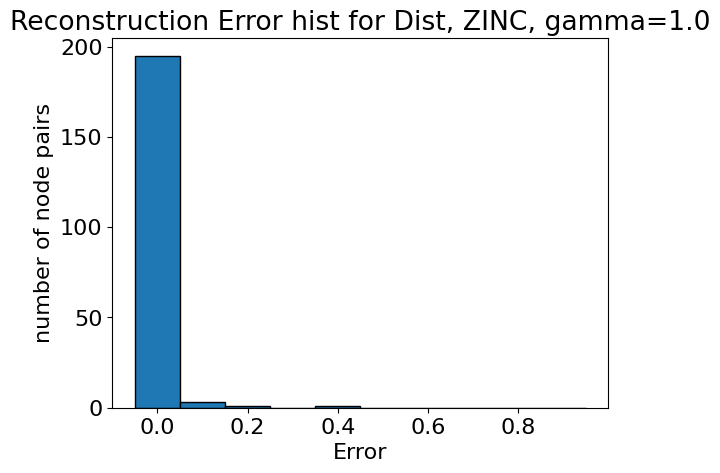

'Dist, Peptides, gamma=0.0: reconstruction error mean = 0.0, std = 0.0'

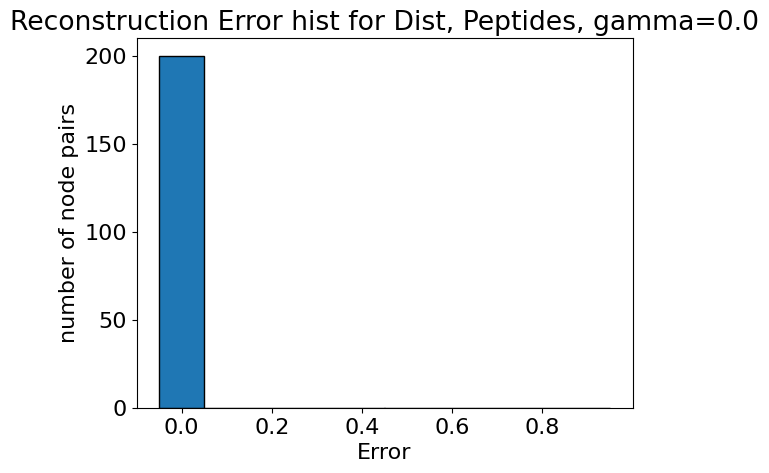

'Dist, Peptides, gamma=0.3: reconstruction error mean = 0.0942712053656578, std = 0.08322586864233017'

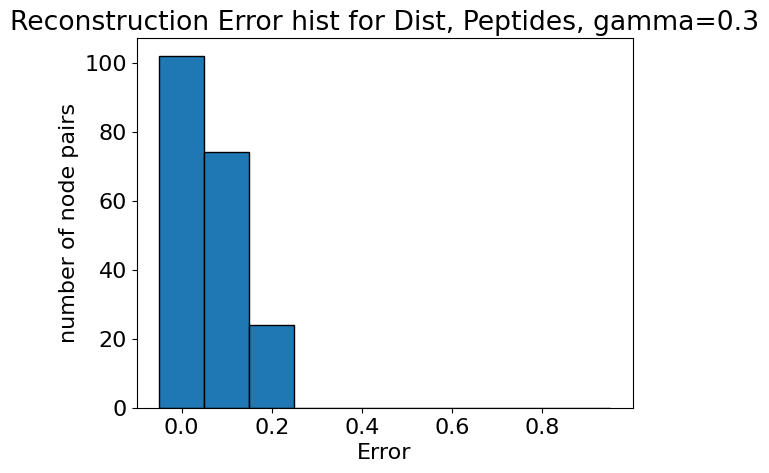

'Dist, Peptides, gamma=1.0: reconstruction error mean = 0.15154194831848145, std = 0.09552162140607834'

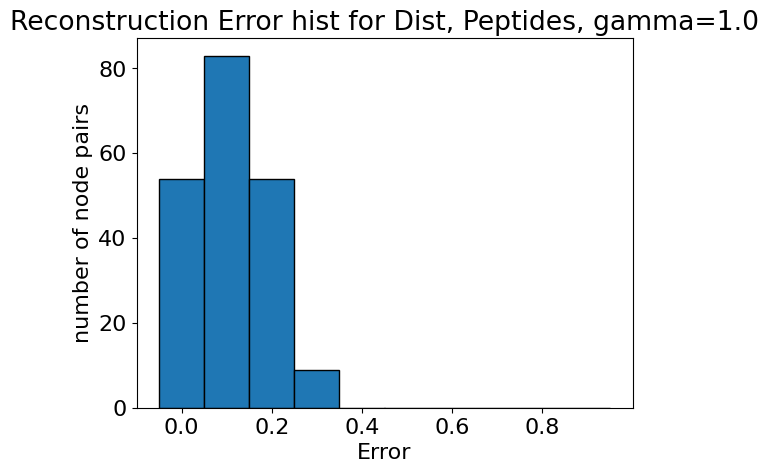

'Dist, CIFAR, gamma=0.0: reconstruction error mean = 0.0, std = 0.0'

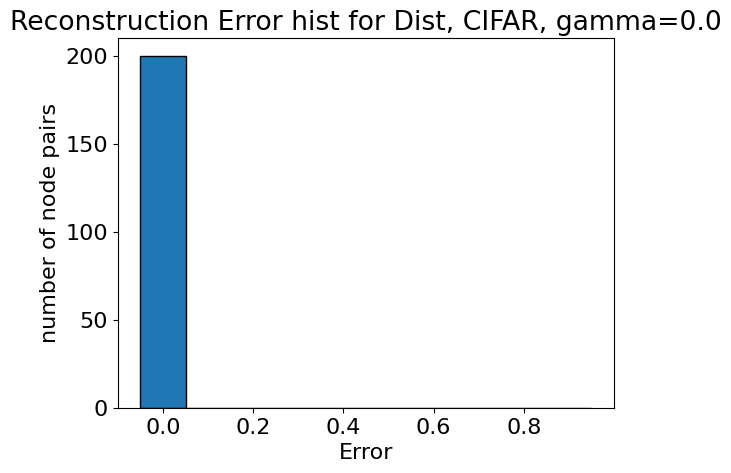

'Dist, CIFAR, gamma=0.3: reconstruction error mean = 0.07854552567005157, std = 0.021401353180408478'

KeyboardInterrupt: 

In [69]:
plot_error({f"Dist, ZINC, gamma={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]})
plot_error({f"Dist, Peptides, gamma={g}": BASE_PATH + f"lpca_with_sim_new_Peptides_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]})
plot_error({f"Dist, CIFAR, gamma={g}": BASE_PATH + f"lpca_with_sim_new_CIFAR_methodDist_k12_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]})

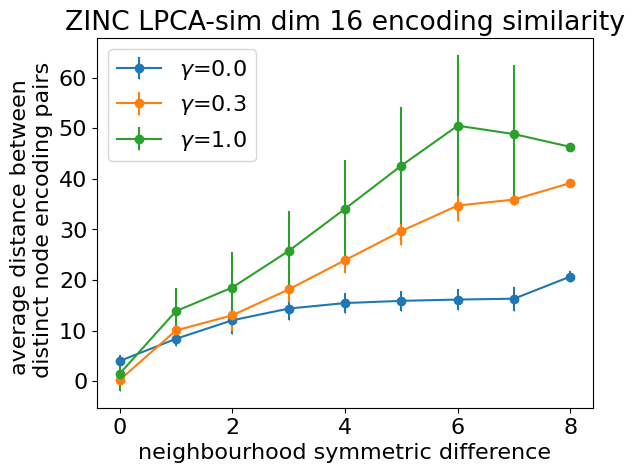

In [44]:
plot_neighbourhood_distance_multiple({r'$\gamma$' + f"={g}": SIM_PATH + f"similarity_lpca_with_sim_new_ZINC_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]}, "ZINC LPCA-sim dim 16 encoding similarity")

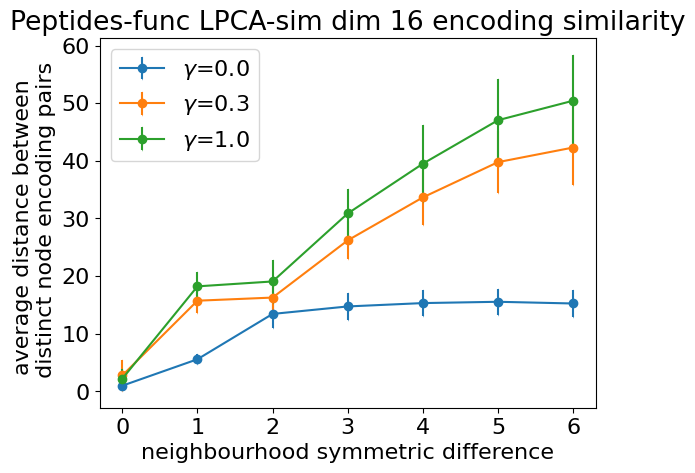

In [56]:
plot_neighbourhood_distance_multiple({r'$\gamma$' + f"={g}": SIM_PATH + f"similarity_lpca_with_sim_new_Peptides_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]}, "Peptides-func LPCA-sim dim 16 encoding similarity")

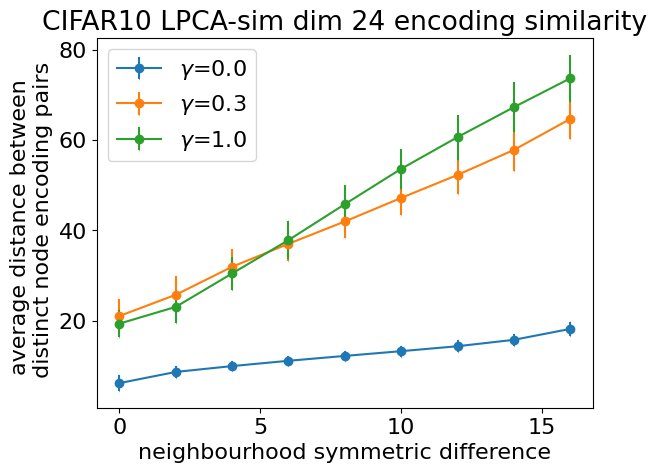

In [54]:
    plot_neighbourhood_distance_multiple({r'$\gamma$' + f"={g}": SIM_PATH + f"similarity_lpca_with_sim_new_CIFAR_methodDist_k12_b4_gamma{g}_s200.parquet" for g in [0.0, 0.3, 1.0]}, "CIFAR10 LPCA-sim dim 24 encoding similarity")

plot_neighbourhood_similarity_multiple({r'$\gamma$' + f"={g}": SIM_PATH + f"similarity_lpca_with_sim_new_ZINC_k8_b4_gamma{g}_sNone.parquet" for g in [1.0]}, "ZINC LPCA-sim dim 16 encoding similarity")
plot_neighbourhood_similarity_multiple({r'$\gamma$' + f"={g}": SIM_PATH + f"similarity_lpca_with_sim_new_ZINC_k8_b4_gamma{g}_sNone.parquet" for g in [1.0]}, "ZINC LPCA-sim dim 16 encoding similarity")## ZINC


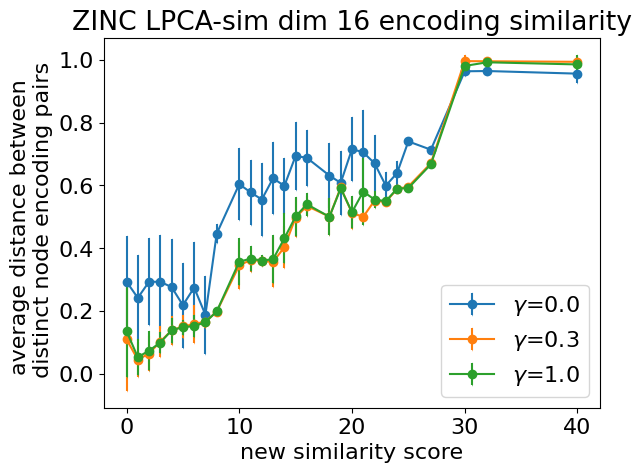

In [77]:
plot_neighbourhood_similarity_multiple({r'$\gamma$' + f"={g}": SIM_PATH + f"similarity_lpca_with_sim_new_ZINC_methodSim_k8_b4_gamma{g}_s200_norm.parquet" for g in [0.0, 0.3, 1.0]}, "ZINC LPCA-sim dim 16 encoding similarity")


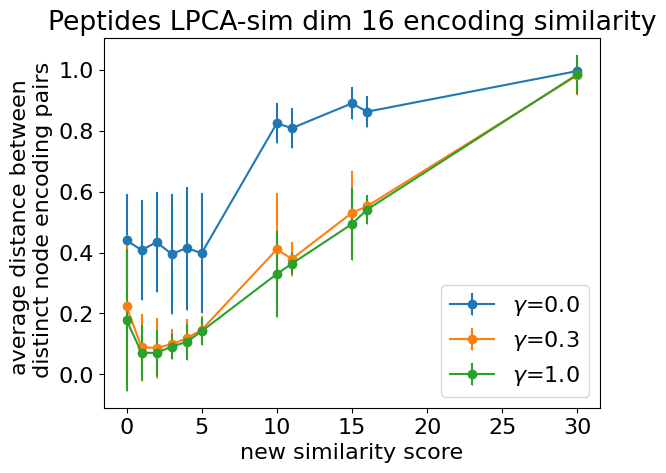

In [78]:
plot_neighbourhood_similarity_multiple({r'$\gamma$' + f"={g}": SIM_PATH + f"similarity_lpca_with_sim_new_Peptides_methodSim_k8_b4_gamma{g}_s200_norm.parquet" for g in [0.0, 0.3, 1.0]}, "Peptides LPCA-sim dim 16 encoding similarity")

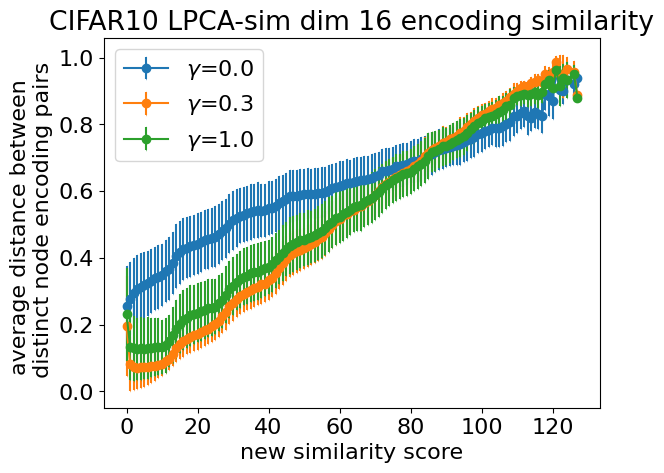

In [79]:
plot_neighbourhood_similarity_multiple({r'$\gamma$' + f"={g}": SIM_PATH + f"similarity_lpca_with_sim_new_CIFAR_methodSim_k12_b4_gamma{g}_s200_norm.parquet" for g in [0.0, 0.3, 1.0]}, "CIFAR10 LPCA-sim dim 16 encoding similarity")

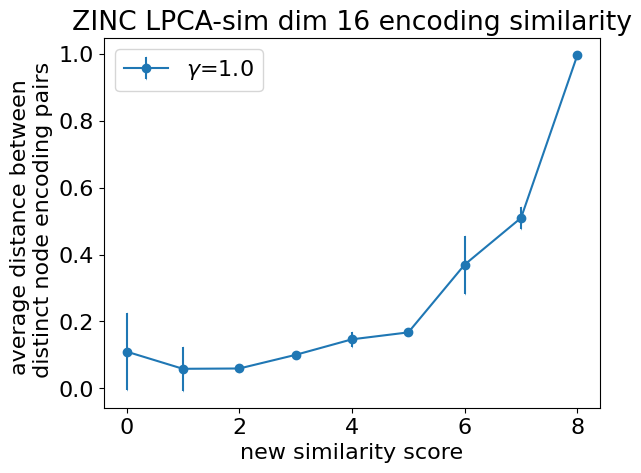

In [18]:
plot_neighbourhood_similarity_single({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodSim_k8_b4_gamma{g}_s200.parquet" for g in [1.0]}, 10, "ZINC LPCA-sim dim 16 encoding similarity")

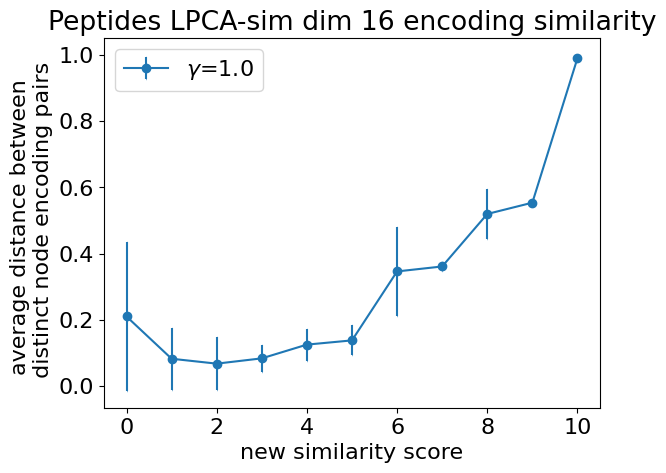

In [19]:
plot_neighbourhood_similarity_single({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_Peptides_methodSim_k8_b4_gamma{g}_s200.parquet" for g in [1.0]}, 2, "Peptides LPCA-sim dim 16 encoding similarity")

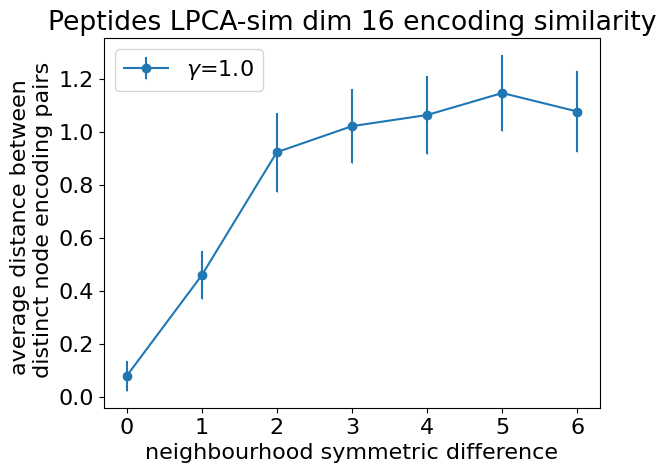

In [23]:
plot_neighbourhood_distance_single({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_Peptides_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [1.0]}, 0, "Peptides LPCA-sim dim 16 encoding similarity")

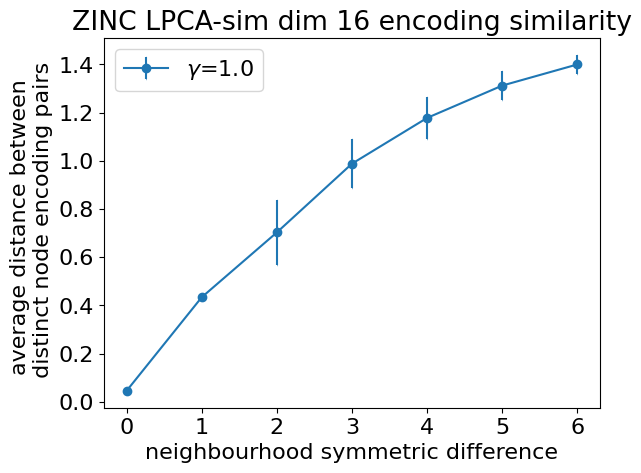

In [83]:
plot_neighbourhood_distance_single({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodDist_k8_b4_gamma{g}_s200.parquet" for g in [1.0]}, 10, "ZINC LPCA-sim dim 16 encoding similarity")

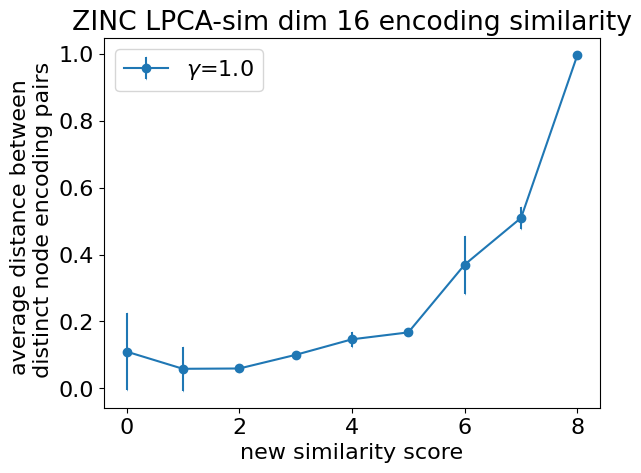

In [89]:
plot_neighbourhood_similarity_single({r'$\gamma$' + f"={g}": BASE_PATH + f"lpca_with_sim_new_ZINC_methodSim_k8_b4_gamma{g}_s200.parquet" for g in [1.0]}, 10, "ZINC LPCA-sim dim 16 encoding similarity")